# 01 - Preprocesamiento de formularios E14

Este notebook lee formularios desde `data/raw/`, los convierte a imagen, mejora la calidad y genera recortes automáticos para OCR.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.append(str(ROOT))

from src.preprocessing import (
    ensure_dirs, list_input_files, process_one_file, process_all_files,
    RAW_DIR, PROCESSED_DIR, CROPS_DIR, OUTPUT_DIR
)
ensure_dirs()
print('Carpetas listas')

Carpetas listas


## 1. formularios en `data/raw/`

 `E14_001.pdf` hasta `E14_017.pdf`.

In [2]:
files = list_input_files(RAW_DIR)
print(f'Formularios encontrados: {len(files)}')
for f in files:
    print('-', f)

Formularios encontrados: 17
- C:\Users\muril\Documents\GitHub\deteccion-fraude-d14\data\raw\E14Cali_Zona13_01\E14_001.pdf
- C:\Users\muril\Documents\GitHub\deteccion-fraude-d14\data\raw\E14Cali_Zona13_01\E14_002.pdf
- C:\Users\muril\Documents\GitHub\deteccion-fraude-d14\data\raw\E14Cali_Zona13_01\E14_003.pdf
- C:\Users\muril\Documents\GitHub\deteccion-fraude-d14\data\raw\E14Cali_Zona13_01\E14_004.pdf
- C:\Users\muril\Documents\GitHub\deteccion-fraude-d14\data\raw\E14Cali_Zona13_01\E14_005.pdf
- C:\Users\muril\Documents\GitHub\deteccion-fraude-d14\data\raw\E14Cali_Zona13_01\E14_006.pdf
- C:\Users\muril\Documents\GitHub\deteccion-fraude-d14\data\raw\E14Cali_Zona13_01\E14_007.pdf
- C:\Users\muril\Documents\GitHub\deteccion-fraude-d14\data\raw\E14Cali_Zona13_01\E14_008.pdf
- C:\Users\muril\Documents\GitHub\deteccion-fraude-d14\data\raw\E14Cali_Zona13_01\E14_009.pdf
- C:\Users\muril\Documents\GitHub\deteccion-fraude-d14\data\raw\E14Cali_Zona13_01\E14_010.pdf
- C:\Users\muril\Documents\GitHu

## 2. Probar con un solo formulario

In [3]:
if not files:
    raise FileNotFoundError('No hay formularios en data/raw/. Agrega tus E14 allí.')

test_file = files[0]
print('Probando con:', test_file)
records = process_one_file(test_file)
records[:3]

Probando con: C:\Users\muril\Documents\GitHub\deteccion-fraude-d14\data\raw\E14Cali_Zona13_01\E14_001.pdf


[{'form_id': 'E14_001',
  'field': 'total_sufragantes',
  'crop_path': 'C:/Users/muril/Documents/GitHub/deteccion-fraude-d14/data/crops/E14_001/total_sufragantes.png',
  'x1': 48,
  'y1': 417,
  'x2': 304,
  'y2': 463,
  'source_file': 'C:/Users/muril/Documents/GitHub/deteccion-fraude-d14/data/raw/E14Cali_Zona13_01/E14_001.pdf',
  'processed_path': 'C:/Users/muril/Documents/GitHub/deteccion-fraude-d14/data/processed/E14_001/E14_001_processed.png'},
 {'form_id': 'E14_001',
  'field': 'votos_en_urna',
  'crop_path': 'C:/Users/muril/Documents/GitHub/deteccion-fraude-d14/data/crops/E14_001/votos_en_urna.png',
  'x1': 357,
  'y1': 417,
  'x2': 611,
  'y2': 463,
  'source_file': 'C:/Users/muril/Documents/GitHub/deteccion-fraude-d14/data/raw/E14Cali_Zona13_01/E14_001.pdf',
  'processed_path': 'C:/Users/muril/Documents/GitHub/deteccion-fraude-d14/data/processed/E14_001/E14_001_processed.png'},
 {'form_id': 'E14_001',
  'field': 'votos_incinerados',
  'crop_path': 'C:/Users/muril/Documents/GitH

## 3. Revisar vista previa de recortes

los cuadros rojos se ajustan corriendo el script `ver_coordenadas.py`

In [4]:
from IPython.display import Image, display
from pathlib import Path

previews = sorted(OUTPUT_DIR.glob("*preview_recortes.png"))

print("Previews encontrados:")
for p in previews:
    print(p)

if previews:
    display(Image(filename=str(previews[0])))
else:
    print("No se encontró ningún preview en data/output/")

Previews encontrados:
No se encontró ningún preview en data/output/


## 4. Revisar recortes generados

In [5]:
from pathlib import Path

carpetas = sorted(CROPS_DIR.iterdir())

for c in carpetas:
    print(c.name)

form_id = carpetas[0].name

print("Usando:", form_id)

E14_001
Usando: E14_001


C:\Users\muril\Documents\GitHub\deteccion-fraude-d14\data\crops\E14_001\total_sufragantes.png


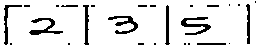

C:\Users\muril\Documents\GitHub\deteccion-fraude-d14\data\crops\E14_001\votos_en_urna.png


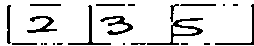

C:\Users\muril\Documents\GitHub\deteccion-fraude-d14\data\crops\E14_001\votos_candidato_1.png


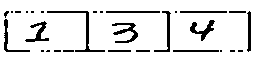

C:\Users\muril\Documents\GitHub\deteccion-fraude-d14\data\crops\E14_001\votos_candidato_2.png


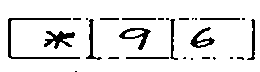

C:\Users\muril\Documents\GitHub\deteccion-fraude-d14\data\crops\E14_001\total_mesa.png


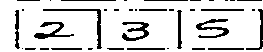

In [6]:
crop_examples = [
    CROPS_DIR / form_id / 'total_sufragantes.png',
    CROPS_DIR / form_id / 'votos_en_urna.png',
    CROPS_DIR / form_id / 'votos_candidato_1.png',
    CROPS_DIR / form_id / 'votos_candidato_2.png',
    CROPS_DIR / form_id / 'total_mesa.png',
]

for crop in crop_examples:
    print(crop)
    if crop.exists():
        display(Image(filename=str(crop)))

## 5. Procesar todos los formularios

In [7]:
df_crops = process_all_files(RAW_DIR)
df_crops.head(10)

Procesando: C:\Users\muril\Documents\GitHub\deteccion-fraude-d14\data\raw\E14Cali_Zona13_01\E14_001.pdf
Procesando: C:\Users\muril\Documents\GitHub\deteccion-fraude-d14\data\raw\E14Cali_Zona13_01\E14_002.pdf
Procesando: C:\Users\muril\Documents\GitHub\deteccion-fraude-d14\data\raw\E14Cali_Zona13_01\E14_003.pdf
Procesando: C:\Users\muril\Documents\GitHub\deteccion-fraude-d14\data\raw\E14Cali_Zona13_01\E14_004.pdf
Procesando: C:\Users\muril\Documents\GitHub\deteccion-fraude-d14\data\raw\E14Cali_Zona13_01\E14_005.pdf
Procesando: C:\Users\muril\Documents\GitHub\deteccion-fraude-d14\data\raw\E14Cali_Zona13_01\E14_006.pdf
Procesando: C:\Users\muril\Documents\GitHub\deteccion-fraude-d14\data\raw\E14Cali_Zona13_01\E14_007.pdf
Procesando: C:\Users\muril\Documents\GitHub\deteccion-fraude-d14\data\raw\E14Cali_Zona13_01\E14_008.pdf
Procesando: C:\Users\muril\Documents\GitHub\deteccion-fraude-d14\data\raw\E14Cali_Zona13_01\E14_009.pdf
Procesando: C:\Users\muril\Documents\GitHub\deteccion-fraude-d14

,form_id,field,crop_path,x1,y1,x2,y2,source_file,processed_path
0,E14_001,total_sufragantes,C:/Users/muril/Documents/GitHub/deteccion-frau...,48,417,304,463,C:/Users/muril/Documents/GitHub/deteccion-frau...,C:/Users/muril/Documents/GitHub/deteccion-frau...
1,E14_001,votos_en_urna,C:/Users/muril/Documents/GitHub/deteccion-frau...,357,417,611,463,C:/Users/muril/Documents/GitHub/deteccion-frau...,C:/Users/muril/Documents/GitHub/deteccion-frau...
2,E14_001,votos_incinerados,C:/Users/muril/Documents/GitHub/deteccion-frau...,672,422,927,462,C:/Users/muril/Documents/GitHub/deteccion-frau...,C:/Users/muril/Documents/GitHub/deteccion-frau...
3,E14_001,votos_candidato_1,C:/Users/muril/Documents/GitHub/deteccion-frau...,674,552,936,617,C:/Users/muril/Documents/GitHub/deteccion-frau...,C:/Users/muril/Documents/GitHub/deteccion-frau...
4,E14_001,votos_candidato_2,C:/Users/muril/Documents/GitHub/deteccion-frau...,670,710,930,782,C:/Users/muril/Documents/GitHub/deteccion-frau...,C:/Users/muril/Documents/GitHub/deteccion-frau...
5,E14_001,votos_blanco,C:/Users/muril/Documents/GitHub/deteccion-frau...,669,825,925,876,C:/Users/muril/Documents/GitHub/deteccion-frau...,C:/Users/muril/Documents/GitHub/deteccion-frau...
6,E14_001,votos_nulos,C:/Users/muril/Documents/GitHub/deteccion-frau...,670,875,925,923,C:/Users/muril/Documents/GitHub/deteccion-frau...,C:/Users/muril/Documents/GitHub/deteccion-frau...
7,E14_001,votos_no_marcados,C:/Users/muril/Documents/GitHub/deteccion-frau...,675,918,922,964,C:/Users/muril/Documents/GitHub/deteccion-frau...,C:/Users/muril/Documents/GitHub/deteccion-frau...
8,E14_001,total_mesa,C:/Users/muril/Documents/GitHub/deteccion-frau...,662,960,925,1012,C:/Users/muril/Documents/GitHub/deteccion-frau...,C:/Users/muril/Documents/GitHub/deteccion-frau...
9,E14_002,total_sufragantes,C:/Users/muril/Documents/GitHub/deteccion-frau...,48,417,304,463,C:/Users/muril/Documents/GitHub/deteccion-frau...,C:/Users/muril/Documents/GitHub/deteccion-frau...


## Salidas esperadas

- `data/processed/E14_001_processed.png`
- `data/crops/E14_001/total_mesa.png`
- `data/output/crops_index.csv`